In [26]:
import os
import sys
#pointing python to project root
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from ingestion.db import get_engine
import warnings

warnings.filterwarnings("ignore")

engine =  get_engine()
df = pd.read_sql("SELECT * FROM weather_readings ORDER BY timestamp ASC", engine)
print(f"Loaded {len(df)} rows")

df.head()


Loaded 744 rows


,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          744 non-null    int64         
 1   timestamp                   744 non-null    datetime64[ns]
 2   station_id                  744 non-null    object        
 3   temperature_2m              744 non-null    float64       
 4   shortwave_radiation         744 non-null    float64       
 5   windspeed_10m               744 non-null    float64       
 6   wind_direction_10m          744 non-null    float64       
 7   wind_gusts_10m              744 non-null    float64       
 8   relative_humidity_2m        744 non-null    float64       
 9   rain                        744 non-null    float64       
 10  cloud_cover                 744 non-null    float64       
 11  soil_temperature_7_to_28cm  744 non-null    float64       

In [28]:
df.describe()

,id,timestamp,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
count,744.000000,744,744.000000,744.000000,744.00000,744.000000,744.000000,744.000000,744.0,744.000000,744.000000,744.000000
mean,372.500000,2024-01-16 11:29:59.999999744,19.986290,265.766129,10.71129,67.786290,20.952285,22.350806,0.0,16.610215,21.811559,0.278559
min,1.000000,2024-01-01 00:00:00,10.600000,0.000000,1.10000,15.000000,3.600000,8.000000,0.0,0.000000,19.400000,0.277000
25%,186.750000,2024-01-08 17:45:00,15.675000,0.000000,9.00000,53.000000,14.800000,16.000000,0.0,0.000000,21.100000,0.278000
50%,372.500000,2024-01-16 11:30:00,18.900000,2.000000,11.00000,65.000000,19.100000,22.000000,0.0,0.000000,21.800000,0.279000
75%,558.250000,2024-01-24 05:15:00,24.700000,584.250000,12.40000,75.000000,27.700000,28.000000,0.0,10.250000,22.500000,0.279000
max,744.000000,2024-01-31 23:00:00,30.200000,965.000000,18.50000,360.000000,40.700000,45.000000,0.0,100.000000,23.900000,0.280000
std,214.918589,NaN,5.174414,347.754692,2.59034,31.023089,7.591927,7.723994,0.0,32.458296,1.023453,0.000895


In [29]:
print("shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())

shape: (744, 13)

Missing values:
 id                            0
timestamp                     0
station_id                    0
temperature_2m                0
shortwave_radiation           0
windspeed_10m                 0
wind_direction_10m            0
wind_gusts_10m                0
relative_humidity_2m          0
rain                          0
cloud_cover                   0
soil_temperature_7_to_28cm    0
soil_moisture_7_to_28cm       0
dtype: int64


In [30]:
#fixin datatypes
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["station_id"] = df["station_id"].astype(str)

In [31]:
sensor_cols = [
    "temperature_2m", "shortwave_radiation", "windspeed_10m",
    "wind_direction_10m", "wind_gusts_10m", "relative_humidity_2m",
    "rain", "cloud_cover", "soil_temperature_7_to_28cm", "soil_moisture_7_to_28cm"
]

# for col in sensor_cols:
#     df[f"{col}_missing"] = df[col].isnull().astype(int)


## Removing outliers

In [32]:
bounds = {
    "temperature_2m":             (-10, 50),
    "shortwave_radiation":        (0, 1200),
    "windspeed_10m":              (0, 150),
    "wind_gusts_10m":             (0, 200),
    "relative_humidity_2m":       (0, 100),
    "rain":                       (0, 200),
    "cloud_cover":                (0, 100),
    "soil_temperature_7_to_28cm": (0, 60),
    "soil_moisture_7_to_28cm":    (0, 1.0),
}

for col, (low, high) in bounds.items():
    if col in df.columns:
        mask = (df[col] < low) | (df[col] > high)
        if mask.sum() > 0:
            print(f"{col}: {mask.sum()} outliers removed")
            df.loc[mask, col] = np.nan



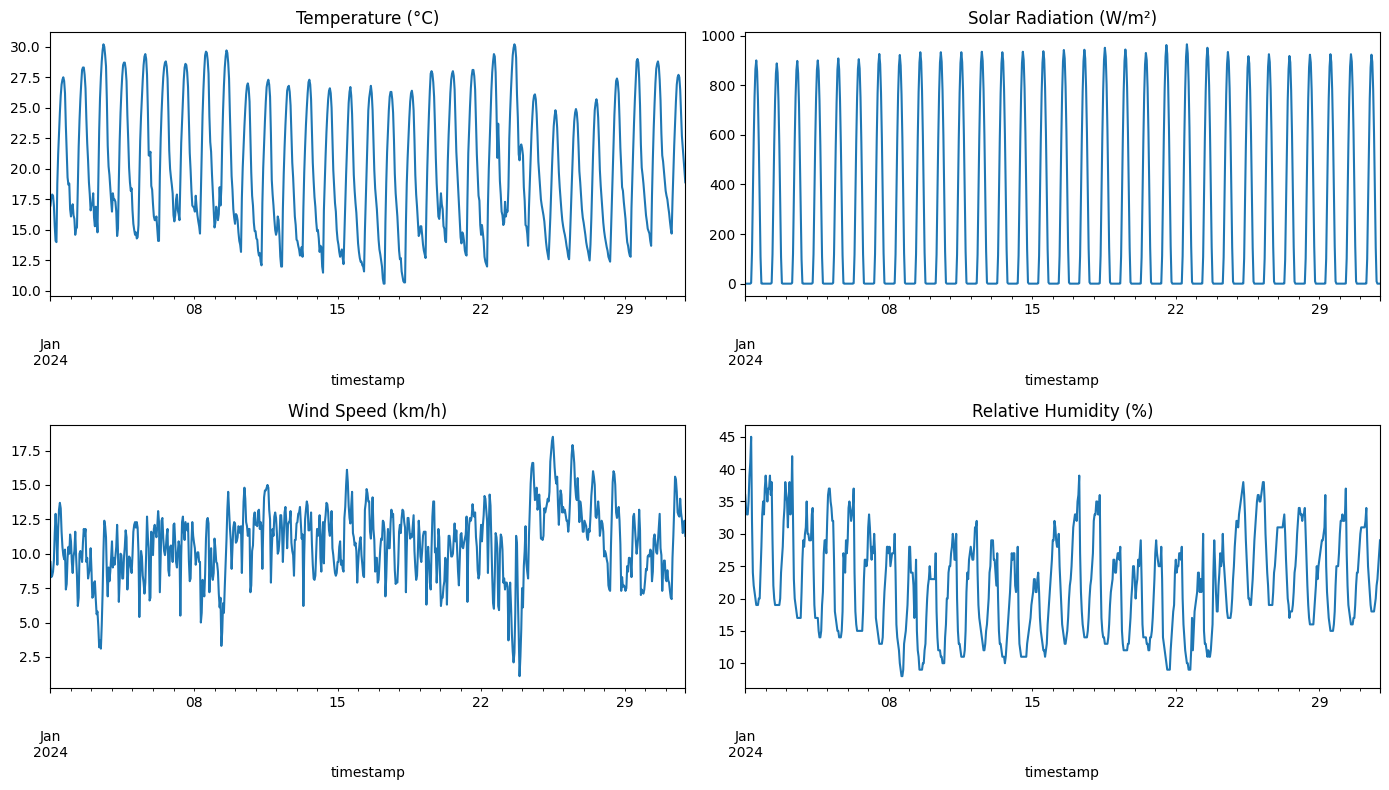

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df.plot(x="timestamp", y="temperature_2m", ax=axes[0,0], title="Temperature (°C)", legend=False)
df.plot(x="timestamp", y="shortwave_radiation", ax=axes[0,1], title="Solar Radiation (W/m²)", legend=False)
df.plot(x="timestamp", y="windspeed_10m", ax=axes[1,0], title="Wind Speed (km/h)", legend=False)
df.plot(x="timestamp", y="relative_humidity_2m", ax=axes[1,1], title="Relative Humidity (%)", legend=False)

plt.tight_layout()
plt.show()

In [34]:
df.head()

,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


## Day 04 - EDA

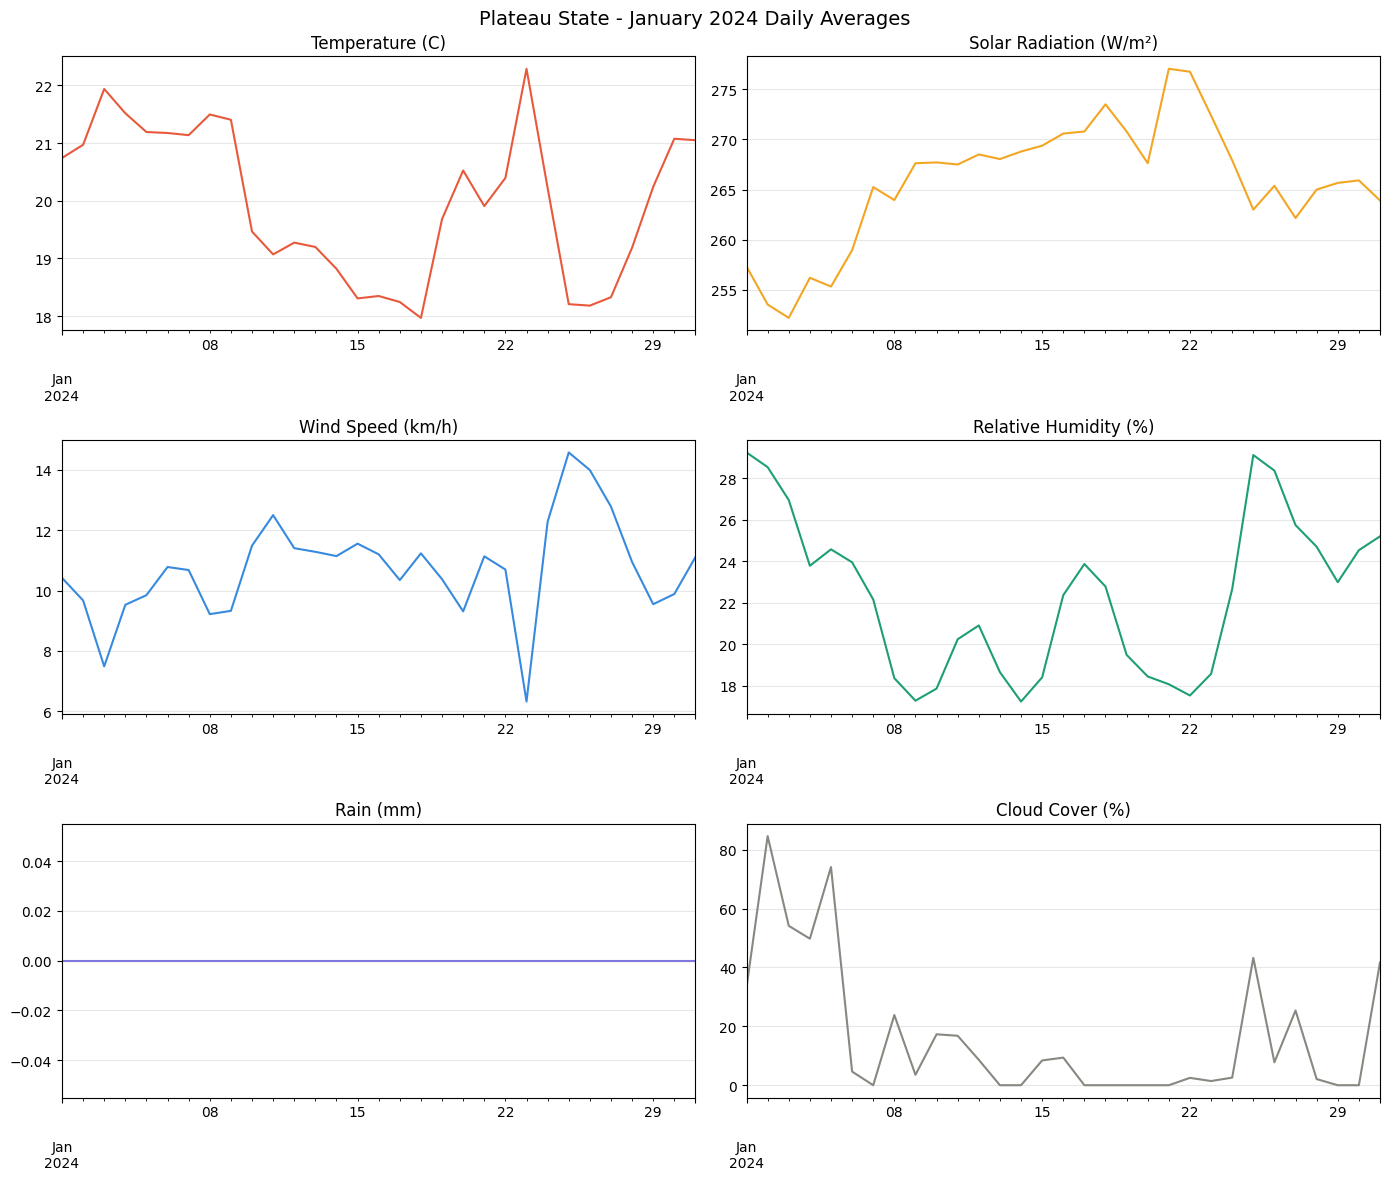

In [43]:
df_plot = df.set_index("timestamp")
daily = df_plot.resample("D").mean(numeric_only=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Plateau State - January 2024 Daily Averages", fontsize=14)

daily["temperature_2m"].plot(ax=axes[0,0], title="Temperature (C)", color="#E8593C")
daily["shortwave_radiation"].plot(ax=axes[0,1], title="Solar Radiation (W/m²)", color="#F2A623")
daily["windspeed_10m"].plot(ax=axes[1,0], title="Wind Speed (km/h)", color="#378ADD")
daily["relative_humidity_2m"].plot(ax=axes[1,1], title="Relative Humidity (%)", color="#1D9E75")
daily["rain"].plot(ax=axes[2,0], title="Rain (mm)", color="#7F77DD")
daily["cloud_cover"].plot(ax=axes[2,1], title="Cloud Cover (%)", color="#888780")

for ax in axes.flat:
    ax.set_xlabel("")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
df_plot.head()
# daily.head()

,id,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,1,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
2024-01-01 01:00:00,2,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2024-01-01 02:00:00,3,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
2024-01-01 03:00:00,4,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
2024-01-01 04:00:00,5,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


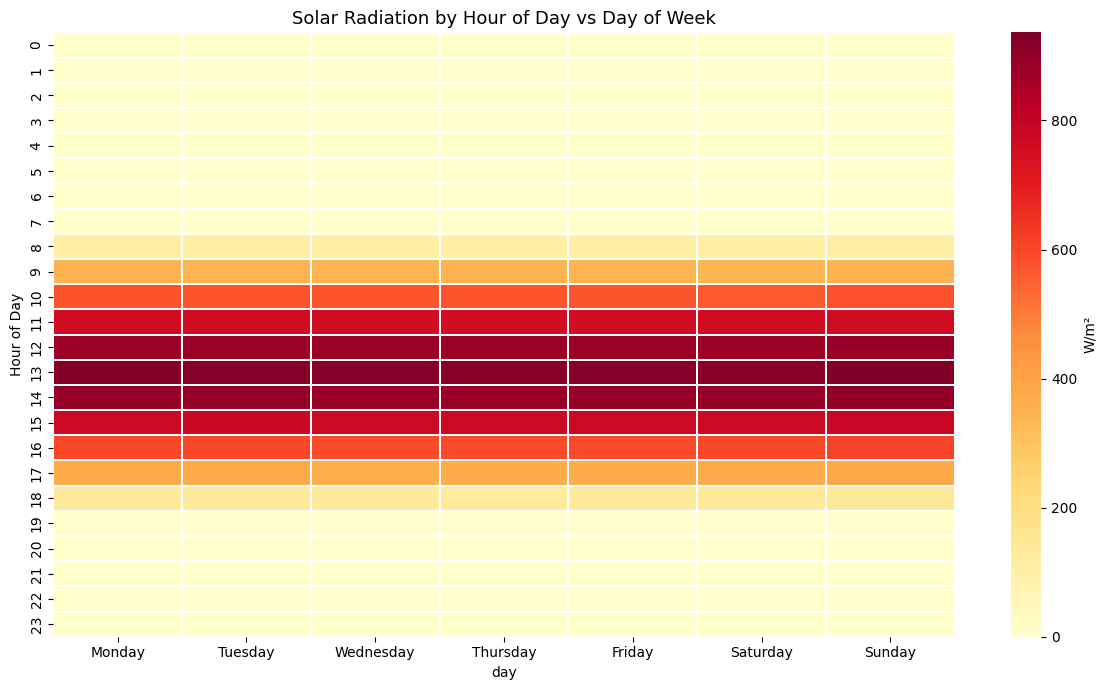

In [50]:
df_heat = df_plot.copy()
df_heat["hour"] = df_heat.index.hour
df_heat["day"] = df_heat.index.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

pivot = df_heat.pivot_table(
    values="shortwave_radiation",
    index="hour",
    columns="day",
    aggfunc="mean"
)[day_order]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3, cbar_kws={"label": "W/m²"})
ax.set_title("Solar Radiation by Hour of Day vs Day of Week", fontsize=13)
ax.set_ylabel("Hour of Day")
plt.tight_layout()
plt.show()

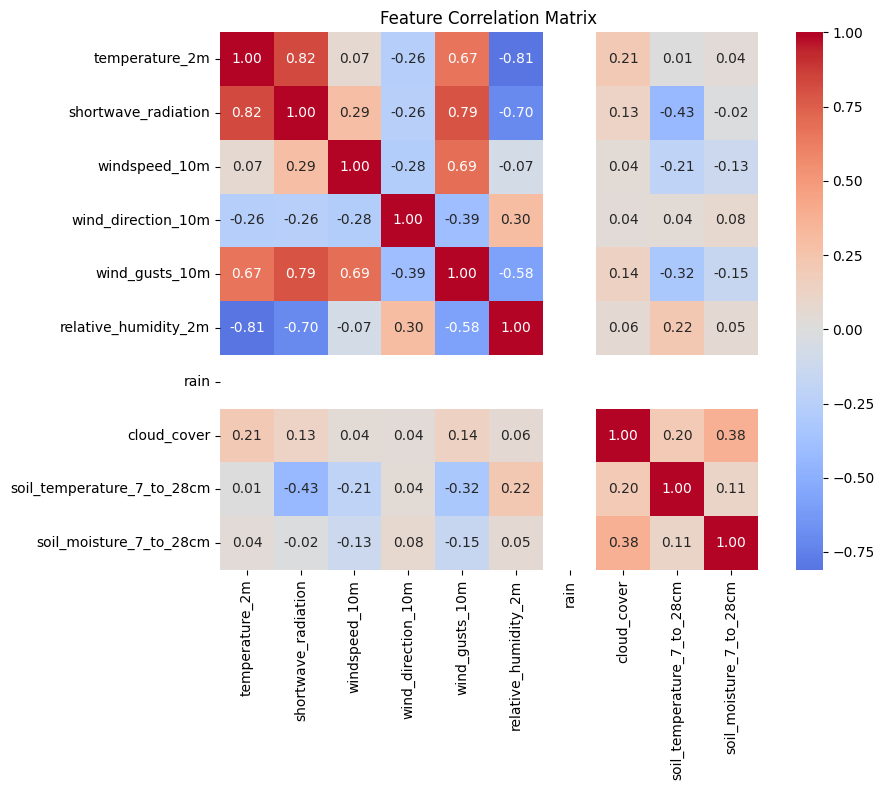

In [56]:
#correlation

fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df[sensor_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [57]:
peak_solar_hour = df_plot.groupby(df_plot.index.hour)["shortwave_radiation"].mean().idxmax()
peak_temp_hour  = df_plot.groupby(df_plot.index.hour)["temperature_2m"].mean().idxmax()

print("Key EDA Findings")
print(f"Peak solar radiation hour : {peak_solar_hour}:00")
print(f"Peak temperature hour     : {peak_temp_hour}:00")
print(f"Average wind speed        : {df['windspeed_10m'].mean():.1f} km/h")
print(f"Max solar radiation       : {df['shortwave_radiation'].max():.1f} W/m²")

Key EDA Findings
Peak solar radiation hour : 13:00
Peak temperature hour     : 15:00
Average wind speed        : 10.7 km/h
Max solar radiation       : 965.0 W/m²


Day 5 -Feature Engineering

In [58]:
df.head()

,id,timestamp,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
0,1,2024-01-01 00:00:00,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
1,2,2024-01-01 01:00:00,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2,3,2024-01-01 02:00:00,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
3,4,2024-01-01 03:00:00,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
4,5,2024-01-01 04:00:00,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [60]:
df = df.set_index("timestamp").sort_index()
df.head()

,id,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,soil_temperature_7_to_28cm,soil_moisture_7_to_28cm
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00,1,plateau_jos,17.0,0.0,9.4,88.0,14.8,36.0,0.0,0.0,22.8,0.28
2024-01-01 01:00:00,2,plateau_jos,17.7,0.0,8.3,90.0,11.9,34.0,0.0,0.0,22.7,0.28
2024-01-01 02:00:00,3,plateau_jos,17.9,0.0,8.4,80.0,11.5,33.0,0.0,0.0,22.5,0.28
2024-01-01 03:00:00,4,plateau_jos,17.8,0.0,8.7,85.0,10.8,33.0,0.0,0.0,22.3,0.28
2024-01-01 04:00:00,5,plateau_jos,17.0,0.0,9.5,81.0,11.9,35.0,0.0,0.0,22.1,0.28


In [61]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["day_of_weel_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

print("Time + cyclical features added")

Time + cyclical features added


In [62]:
target_cols = ["temperature_2m", "shortwave_radiation", "windspeed_10m", "relative_humidity_2m"]

for col in target_cols:
    df[f"{col}_lag1"]  = df[col].shift(1)
    df[f"{col}_lag2"]  = df[col].shift(2)
    df[f"{col}_lag3"]  = df[col].shift(3)
    df[f"{col}_lag24"] = df[col].shift(24)

print(f"Lag features added. Shape: {df.shape}")

Lag features added. Shape: (744, 36)


In [63]:
for col in target_cols:
    df[f"{col}_rolling3h"] = df[col].rolling(window=3, min_periods=1).mean()
    df[f"{col}_rolling6h"] = df[col].rolling(window=6, min_periods=1).mean()
    df[f"{col}_rolling24h"] = df[col].rolling(window=24, min_periods=1).mean()

print(f"Rolling features adde. Shape: {df.shape}")

Rolling features adde. Shape: (744, 48)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 744 entries, 2024-01-01 00:00:00 to 2024-01-31 23:00:00
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id                               744 non-null    int64  
 1   station_id                       744 non-null    object 
 2   temperature_2m                   744 non-null    float64
 3   shortwave_radiation              744 non-null    float64
 4   windspeed_10m                    744 non-null    float64
 5   wind_direction_10m               744 non-null    float64
 6   wind_gusts_10m                   744 non-null    float64
 7   relative_humidity_2m             744 non-null    float64
 8   rain                             744 non-null    float64
 9   cloud_cover                      744 non-null    float64
 10  soil_temperature_7_to_28cm       744 non-null    float64
 11  soil_moisture_7_to_28cm          744 non-null  

In [65]:
df = df.dropna(subset=[f"{col}_lag24" for col in target_cols])
print(f"Final shape after dropping lag NaN rows: {df.shape}")

df.head()

Final shape after dropping lag NaN rows: (720, 48)


,id,station_id,temperature_2m,shortwave_radiation,windspeed_10m,wind_direction_10m,wind_gusts_10m,relative_humidity_2m,rain,cloud_cover,...,temperature_2m_rolling24h,shortwave_radiation_rolling3h,shortwave_radiation_rolling6h,shortwave_radiation_rolling24h,windspeed_10m_rolling3h,windspeed_10m_rolling6h,windspeed_10m_rolling24h,relative_humidity_2m_rolling3h,relative_humidity_2m_rolling6h,relative_humidity_2m_rolling24h
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-02 00:00:00,25,plateau_jos,16.1,0.0,10.9,73.0,14.8,39.0,0.0,100.0,...,20.704167,0.0,0.166667,257.333333,10.766667,10.050000,10.483333,36.333333,34.166667,29.375000
2024-01-02 01:00:00,26,plateau_jos,16.8,0.0,9.4,83.0,14.0,37.0,0.0,100.0,...,20.666667,0.0,0.000000,257.333333,10.566667,10.316667,10.529167,37.666667,35.666667,29.500000
2024-01-02 02:00:00,27,plateau_jos,17.1,0.0,8.6,92.0,11.9,35.0,0.0,98.0,...,20.633333,0.0,0.000000,257.333333,9.633333,10.133333,10.537500,37.000000,36.000000,29.583333
2024-01-02 03:00:00,28,plateau_jos,16.2,0.0,9.8,84.0,12.2,37.0,0.0,100.0,...,20.566667,0.0,0.000000,257.333333,9.266667,10.016667,10.583333,36.333333,36.333333,29.750000
2024-01-02 04:00:00,29,plateau_jos,15.9,0.0,10.2,82.0,12.2,37.0,0.0,100.0,...,20.520833,0.0,0.000000,257.333333,9.533333,10.050000,10.612500,36.333333,37.000000,29.833333


## Day 06 - Feature Scaling

In [66]:
from sklearn.preprocessing import StandardScaler
import joblib

cols_to_scale = [c for c in df.columns if any([
    c.startswith("temperature"),
    c.startswith("shortwave"),
    c.startswith("windspeed"),
    c.startswith("wind_direction"),
    c.startswith("wind_gusts"),
    c.startswith("relative_humidity"),
    c.startswith("rain"),
    c.startswith("cloud_cover"),
    c.startswith("soil_"),
]) and "_missing" not in c and "_sin" not in c and "_cos" not in c]



In [67]:
cols_to_scale

['temperature_2m',
 'shortwave_radiation',
 'windspeed_10m',
 'wind_direction_10m',
 'wind_gusts_10m',
 'relative_humidity_2m',
 'rain',
 'cloud_cover',
 'soil_temperature_7_to_28cm',
 'soil_moisture_7_to_28cm',
 'temperature_2m_lag1',
 'temperature_2m_lag2',
 'temperature_2m_lag3',
 'temperature_2m_lag24',
 'shortwave_radiation_lag1',
 'shortwave_radiation_lag2',
 'shortwave_radiation_lag3',
 'shortwave_radiation_lag24',
 'windspeed_10m_lag1',
 'windspeed_10m_lag2',
 'windspeed_10m_lag3',
 'windspeed_10m_lag24',
 'relative_humidity_2m_lag1',
 'relative_humidity_2m_lag2',
 'relative_humidity_2m_lag3',
 'relative_humidity_2m_lag24',
 'temperature_2m_rolling3h',
 'temperature_2m_rolling6h',
 'temperature_2m_rolling24h',
 'shortwave_radiation_rolling3h',
 'shortwave_radiation_rolling6h',
 'shortwave_radiation_rolling24h',
 'windspeed_10m_rolling3h',
 'windspeed_10m_rolling6h',
 'windspeed_10m_rolling24h',
 'relative_humidity_2m_rolling3h',
 'relative_humidity_2m_rolling6h',
 'relative_hum

In [69]:
split_date= "2024-01-25"
df_train = df[df.index < split_date]
df_test = df[df.index >= split_date]

scaler = StandardScaler()
scaler.fit(df_train[cols_to_scale])

df_train_scaled = df_train.copy()
df_test_scaled = df_test.copy()

df_train_scaled[cols_to_scale] = scaler.transform(df_train[cols_to_scale])
df_test_scaled[cols_to_scale] = scaler.transform(df_test[cols_to_scale])

print(f"Train: {len(df_train_scaled)} rows")
print(f"Test:  {len(df_test_scaled)} rows")
print(f"\nTrain mean after scaling (should be ~0):\n{df_train_scaled[cols_to_scale[:3]].mean().round(4)}")

Train: 552 rows
Test:  168 rows

Train mean after scaling (should be ~0):
temperature_2m        -0.0
shortwave_radiation   -0.0
windspeed_10m          0.0
dtype: float64


In [ ]:
# saving the scaler and splits

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/splits", exist_ok=True)

joblib.dump(scaler, "../models/scaler.joblib")



In [52]:
pivot

day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
hour,,,,,,,
0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
1,0.0,0.0,0.0,0.00,0.00,0.00,0.00
2,0.0,0.0,0.0,0.00,0.00,0.00,0.00
3,0.0,0.0,0.0,0.00,0.00,0.00,0.00
4,0.0,0.0,0.0,0.00,0.00,0.00,0.00
5,0.0,0.0,0.0,0.00,0.00,0.00,0.00
6,0.0,0.0,0.0,0.00,0.00,0.00,0.00
7,1.8,1.8,1.8,2.00,1.75,1.50,1.50
8,113.2,111.6,110.8,112.25,111.00,108.25,111.25


In [53]:
df_heat["day"]

timestamp
2024-01-01 00:00:00       Monday
2024-01-01 01:00:00       Monday
2024-01-01 02:00:00       Monday
2024-01-01 03:00:00       Monday
2024-01-01 04:00:00       Monday
                         ...    
2024-01-31 19:00:00    Wednesday
2024-01-31 20:00:00    Wednesday
2024-01-31 21:00:00    Wednesday
2024-01-31 22:00:00    Wednesday
2024-01-31 23:00:00    Wednesday
Name: day, Length: 744, dtype: object